# Arbitrage scan

Procura items com spread elevado entre marketplaces (ex: comprar barato em skinbaron, vender em steam).

In [1]:
import polars as pl

marketplaces = ["steam", "skinport", "skinbaron", "csmoney", "skinswap", "haloskins", "uuskins"]
alts = [m for m in marketplaces if m != "steam"]

base = (
    pl.scan_parquet("../data/items.parquet")
      .select(
          [pl.col("name"), pl.col("weapon"), pl.col("type")]
          + [pl.col("keyfigures").struct.field(mp).struct.field("current_price").alias(mp) for mp in marketplaces]
          + [pl.col("keyfigures").struct.field(mp).struct.field("current_volume").alias(f"{mp}_vol") for mp in marketplaces]
      )
      .filter(pl.col("steam").is_not_null())
      .with_columns(pl.min_horizontal(alts).alias("min_alt_price"))
      .with_columns(
          (pl.col("steam") - pl.col("min_alt_price")).alias("spread_abs"),
      )
      .with_columns(
          (pl.col("spread_abs") / pl.col("steam") * 100).round(1).alias("spread_pct")
      )
      .with_columns(
          pl.coalesce([
              pl.when(pl.col(m) == pl.col("min_alt_price")).then(pl.lit(m)).otherwise(None)
              for m in alts
          ]).alias("min_alt_market")
      )
      .collect()
)

print(f"Items com preço Steam + pelo menos 1 alt: {base.height}")

Items com preço Steam + pelo menos 1 alt: 12817


## Top spreads absolutos (com volume suficiente para confiar)

In [2]:
MIN_STEAM_VOL = 5
MIN_PRICE = 5  # USD

filtered = base.filter(
    (pl.col("steam_vol") >= MIN_STEAM_VOL) & (pl.col("steam") >= MIN_PRICE)
)

(
    filtered.sort("spread_abs", descending=True).head(20)
            .select(["name", "weapon", "steam", "min_alt_price", "min_alt_market",
                     "spread_abs", "spread_pct", "steam_vol"])
)

name,weapon,steam,min_alt_price,min_alt_market,spread_abs,spread_pct,steam_vol
str,str,f64,f64,str,f64,f64,f64
"""★ Hand Wraps | Spruce DDPAT (F…","""Unknown""",1305.68,330.31,"""skinswap""",975.37,74.7,9.0
"""M4A4 | Eye of Horus (Minimal W…","""M4A4""",1299.19,423.63,"""skinswap""",875.56,67.4,9.0
"""★ Butterfly Knife | Case Harde…","""Butterfly Knife""",1680.0,826.67,"""skinport""",853.33,50.8,7.0
"""AWP | Containment Breach (Fact…","""AWP""",1326.7,528.34,"""skinswap""",798.36,60.2,5.0
"""AWP | Fade (Factory New)""","""AWP""",1601.26,836.47,"""skinswap""",764.79,47.8,6.0
…,…,…,…,…,…,…,…
"""★ Karambit | Marble Fade (Fact…","""Karambit""",1619.0,955.97,"""skinbaron""",663.03,41.0,7.0
"""★ StatTrak™ Butterfly Knife | …","""Butterfly Knife""",1112.05,449.08,"""skinswap""",662.97,59.6,10.0
"""★ StatTrak™ Skeleton Knife | T…","""Skeleton Knife""",990.0,330.68,"""skinswap""",659.32,66.6,5.0


## Top spreads %

In [3]:
(
    filtered.sort("spread_pct", descending=True).head(20)
            .select(["name", "weapon", "steam", "min_alt_price", "min_alt_market",
                     "spread_pct", "steam_vol"])
)

name,weapon,steam,min_alt_price,min_alt_market,spread_pct,steam_vol
str,str,f64,f64,str,f64,f64
"""Howl Pin""","""Unknown""",58.11,0.0,"""uuskins""",100.0,24.0
"""Souvenir MP5-SD | Co-Processor…","""MP5-SD""",87.8,1.47,"""skinbaron""",98.3,7.0
"""Souvenir Five-SeveN | Coolant …","""Five-SeveN""",5.84,0.14,"""haloskins""",97.6,22.0
"""PP-Bizon | Jungle Slipstream (…","""PP-Bizon""",10.65,0.3,"""csmoney""",97.2,20.0
"""StatTrak™ FAMAS | Meow 36 (Min…","""FAMAS""",8.0,0.25,"""csmoney""",96.9,9.0
…,…,…,…,…,…,…
"""M249 | Midnight Palm (Minimal …","""M249""",6.53,0.57,"""skinswap""",91.3,38.0
"""Five-SeveN | Withered Vine (Fi…","""Five-SeveN""",5.02,0.45,"""csmoney""",91.0,92.0
"""M249 | Humidor (Field-Tested)""","""M249""",22.61,2.05,"""skinswap""",90.9,18.0


## Distribuição dos spreads

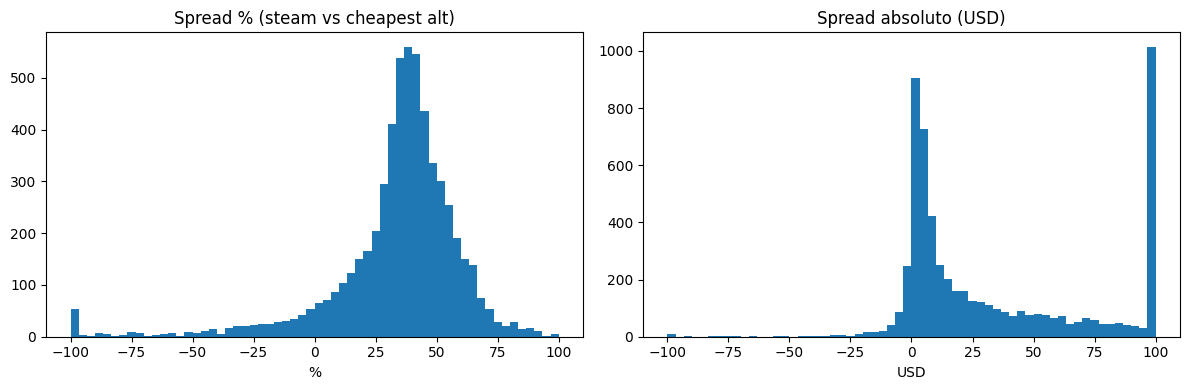

In [4]:
import matplotlib.pyplot as plt

pct = filtered.select(pl.col("spread_pct").clip(-100, 100)).to_series().to_numpy()
absv = filtered.select(pl.col("spread_abs").clip(-100, 100)).to_series().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pct, bins=60)
axes[0].set_title("Spread % (steam vs cheapest alt)")
axes[0].set_xlabel("%")
axes[1].hist(absv, bins=60)
axes[1].set_title("Spread absoluto (USD)")
axes[1].set_xlabel("USD")
plt.tight_layout()
plt.show()

## Marketplace tipicamente mais barato

In [5]:
(
    filtered.group_by("min_alt_market")
            .agg(pl.len().alias("items_cheapest_here"))
            .sort("items_cheapest_here", descending=True)
)

min_alt_market,items_cheapest_here
str,u32
"""skinswap""",2640
"""csmoney""",1932
"""skinbaron""",409
"""skinport""",398
"""haloskins""",387
"""uuskins""",93
